# __2- Model Training__ 

Install torch library

 <span style="color: red;"> RUN IT ONCE IF YOU FACED ERROR IN CELL 3</span>

In [ ]:
!pip install torch torchvision

  Using cached torch-2.10.0-cp311-cp311-win_amd64.whl.metadata (31 kB)
  Using cached torchvision-0.25.0-cp311-cp311-win_amd64.whl.metadata (5.4 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
Using cached torch-2.10.0-cp311-cp311-win_amd64.whl (113.7 MB)
Using cached torchvision-0.25.0-cp311-cp311-win_amd64.whl (4.0 MB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\rahaf\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [1]:
import torch
print(torch.__version__)


2.10.0+cpu


## 2.1 Normlization

In [1]:
import torch # pytorch main libirary
from torchvision import transforms # tp process images
from torch.utils.data import Dataset, DataLoader # Dataset to build a class for data , Dataloader to send data to the model as batches
from PIL import Image # to open images
import pandas as pd # to use train_df/val_df/test_df

transform = transforms.Compose([# غيييررتتتت
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


 Normliazation Equation = $$ \frac{x - mean}{std} = x_{normalized} $$

## 2.2 Dataset Class

 This class is needed to specify how to read images and how to return the image and its label.

In [2]:
class GestureDataset(Dataset):
    def __init__(self, dataframe, transform=None): # to store data & transformers
        self.dataframe = dataframe
        self.transform = transform

        self.label_map = { # Palm -> 0 , Fist -> 1
            "Palm": 0,
            "Fist": 1
        }

    def __len__(self): # Dataloader will use it to know the size of data
        return len(self.dataframe)

    def __getitem__(self, idx):                           # most importent function works like follows:
    
        img_path = self.dataframe.iloc[idx]["image_path"] # 1- take image path
        label = self.dataframe.iloc[idx]["label"]         # 2- open image

        image = Image.open(img_path).convert("RGB")       # 3- convert it to RGB

        if self.transform:                                # 4- apply transform
            image = self.transform(image)

        label = self.label_map[label]                     # 5- convert label to image

        return image, label                               # 6- return (image,label)


## 2.3 Creat Dataset for Each Split 

In [3]:
train_df = pd.read_csv("train.csv")
val_df = pd.read_csv("val.csv")
test_df = pd.read_csv("test.csv")

train_dataset = GestureDataset(train_df, transform=transform)
val_dataset = GestureDataset(val_df, transform=transform)
test_dataset = GestureDataset(test_df, transform=transform)

## 2.3 Creat DataLoder

In [6]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True) # every time pass 32 images
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

## 2.4 Model Prepatation

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

# Load Pretrained ResNet-18 Model
model = models.resnet18(pretrained=True)

num_classes = 2

#  استبدال FC بطبقات أعمق
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, num_classes)
)

# Loss
criterion = nn.CrossEntropyLoss()

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

#  layer3
for param in model.layer3.parameters():
    param.requires_grad = True

# layer4
for param in model.layer4.parameters():
    param.requires_grad = True

# FC بالكامل
for param in model.fc.parameters():
    param.requires_grad = True

# Optimizer
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

## 2.5 Model Training

### The benefits of integrating Validation within Training:

- Monitor performance after each epoch.
- When to stop training (Early Stopping).
- See if the model is actually learning or overfitting.

Epoch [1/10] Train Loss: 0.0916, Train Acc: 96.98% | Val Loss: 0.0162, Val Acc: 99.36%
Epoch [2/10] Train Loss: 0.0318, Train Acc: 99.49% | Val Loss: 0.0124, Val Acc: 99.79%
Epoch [3/10] Train Loss: 0.0247, Train Acc: 99.43% | Val Loss: 0.0297, Val Acc: 99.21%
Epoch [4/10] Train Loss: 0.0119, Train Acc: 99.59% | Val Loss: 0.0105, Val Acc: 99.79%
Epoch [5/10] Train Loss: 0.0148, Train Acc: 99.88% | Val Loss: 0.0067, Val Acc: 99.71%
Epoch [6/10] Train Loss: 0.0109, Train Acc: 99.72% | Val Loss: 0.0185, Val Acc: 99.64%
Epoch [7/10] Train Loss: 0.0109, Train Acc: 99.69% | Val Loss: 0.0098, Val Acc: 99.71%
Epoch [8/10] Train Loss: 0.0051, Train Acc: 99.86% | Val Loss: 0.0026, Val Acc: 99.86%
Epoch [9/10] Train Loss: 0.0042, Train Acc: 99.88% | Val Loss: 0.0074, Val Acc: 99.71%
Epoch [10/10] Train Loss: 0.0047, Train Acc: 99.80% | Val Loss: 0.0059, Val Acc: 99.86%


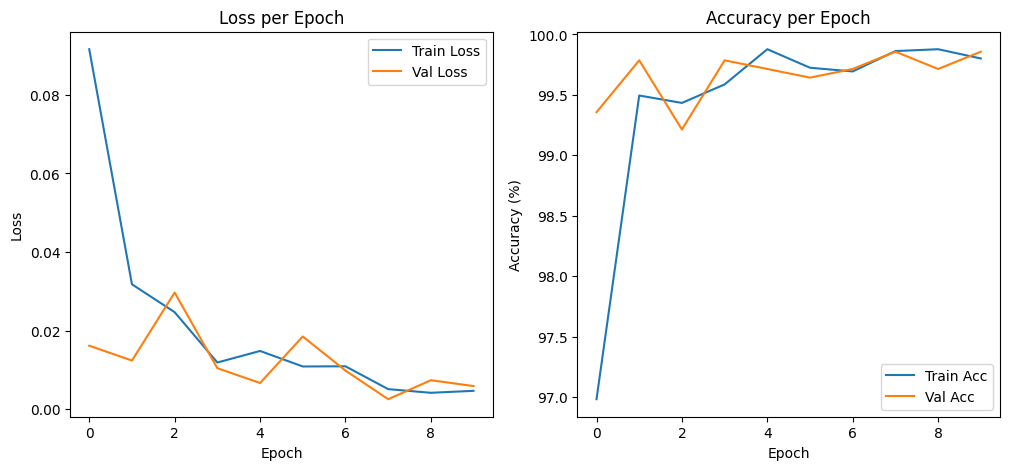

In [8]:
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # if the device has GPU use it, else use CPU
model = model.to(device)

num_epochs = 10 # the num of times the model will go through the data

# used for comparision between each epoch
train_losses = []
train_accs = []
val_losses = []
val_accs = []

best_val_acc = 0.0

for epoch in range(num_epochs): 

    # training
    model.train() # put the model in training mode
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader: # repeat learning process until finish all images
        images, labels = images.to(device), labels.to(device) # put labels and images in the same device
        optimizer.zero_grad() # make old values = 0 every time
         # Forward Pass
        outputs = model(images) # model recaive image, pass it through layers, give possibility
        loss = criterion(outputs, labels) # calculate the diffrance between the prediction and the real value
         # Backward Pass
        loss.backward() 
        optimizer.step() # Adam updates the weights to reduce the loss

        # حساب الإحصائيات
        running_loss += loss.item() 
        _, predicted = torch.max(outputs, 1) # take highest prediction
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # validation 
    model.eval() # put the model in validation mode
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_acc = 100 * val_correct / val_total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    # to save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")

    # print result
    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

# draw graphs
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss per Epoch")

plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.title("Accuracy per Epoch")

plt.show()


##### Trainig & validation results using the original dataset : epoch = 10 , batch size = 32 , lr = 1e-4 

###### Epoch [1/10] Train Loss: 0.0672, Train Acc: 98.66% | Val Loss: 0.0428, Val Acc: 99.57%
###### Epoch [2/10] Train Loss: 0.0609, Train Acc: 99.01% | Val Loss: 0.0402, Val Acc: 99.67%
###### Epoch [3/10] Train Loss: 0.0556, Train Acc: 99.07% | Val Loss: 0.0372, Val Acc: 99.67%
###### Epoch [4/10] Train Loss: 0.0536, Train Acc: 98.97% | Val Loss: 0.0349, Val Acc: 99.62%
###### Epoch [5/10] Train Loss: 0.0514, Train Acc: 99.06% | Val Loss: 0.0324, Val Acc: 99.62%
###### Epoch [6/10] Train Loss: 0.0479, Train Acc: 99.11% | Val Loss: 0.0297, Val Acc: 99.86%
###### Epoch [7/10] Train Loss: 0.0464, Train Acc: 99.09% | Val Loss: 0.0275, Val Acc: 99.86%
###### Epoch [8/10] Train Loss: 0.0424, Train Acc: 99.19% | Val Loss: 0.0297, Val Acc: 99.71%
###### Epoch [9/10] Train Loss: 0.0414, Train Acc: 99.28% | Val Loss: 0.0250, Val Acc: 99.67%
###### Epoch [10/10] Train Loss: 0.0356, Train Acc: 99.40% | Val Loss: 0.0210, Val Acc: 99.90%

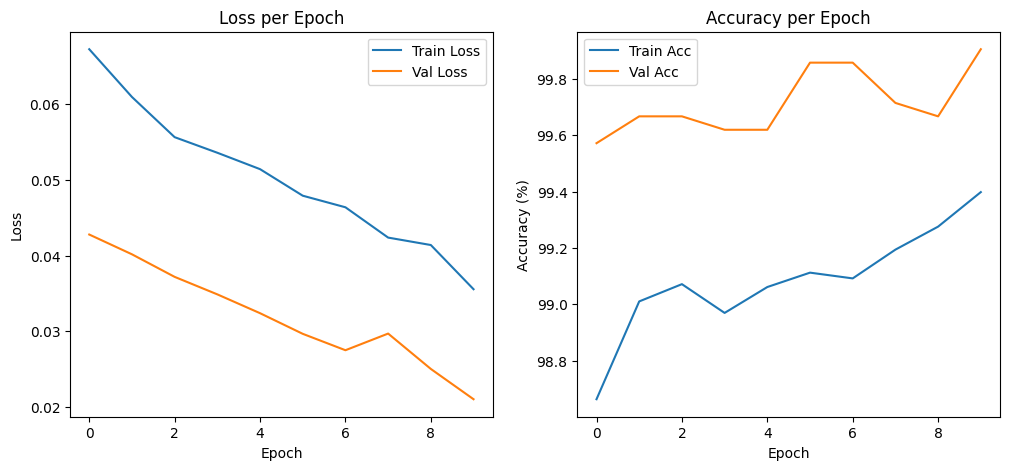

##### Trainig & validation results using our photos + the dataset : epoch = 10 , batch size = 32 , lr = 1e-4 

###### Epoch [1/10] Train Loss: 0.6154, Train Acc: 67.74% | Val Loss: 0.5348, Val Acc: 78.06%

###### Epoch [2/10] Train Loss: 0.4940, Train Acc: 81.18% | Val Loss: 0.4456, Val Acc: 84.30%

###### Epoch [3/10] Train Loss: 0.4255, Train Acc: 84.91% | Val Loss: 0.3991, Val Acc: 86.30%

###### Epoch [4/10] Train Loss: 0.3849, Train Acc: 86.66% | Val Loss: 0.3461, Val Acc: 89.92%

###### Epoch [5/10] Train Loss: 0.3548, Train Acc: 88.28% | Val Loss: 0.3285, Val Acc: 89.38%

###### Epoch [6/10] Train Loss: 0.3325, Train Acc: 88.26% | Val Loss: 0.3151, Val Acc: 89.38%

###### Epoch [7/10] Train Loss: 0.3195, Train Acc: 88.69% | Val Loss: 0.2936, Val Acc: 90.45%

###### Epoch [8/10] Train Loss: 0.3088, Train Acc: 88.59% | Val Loss: 0.2783, Val Acc: 90.45%

###### Epoch [9/10] Train Loss: 0.2850, Train Acc: 90.27% | Val Loss: 0.2657, Val Acc: 92.22%

###### Epoch [10/10] Train Loss: 0.2737, Train Acc: 90.78% | Val Loss: 0.2548, Val Acc: 92.76%

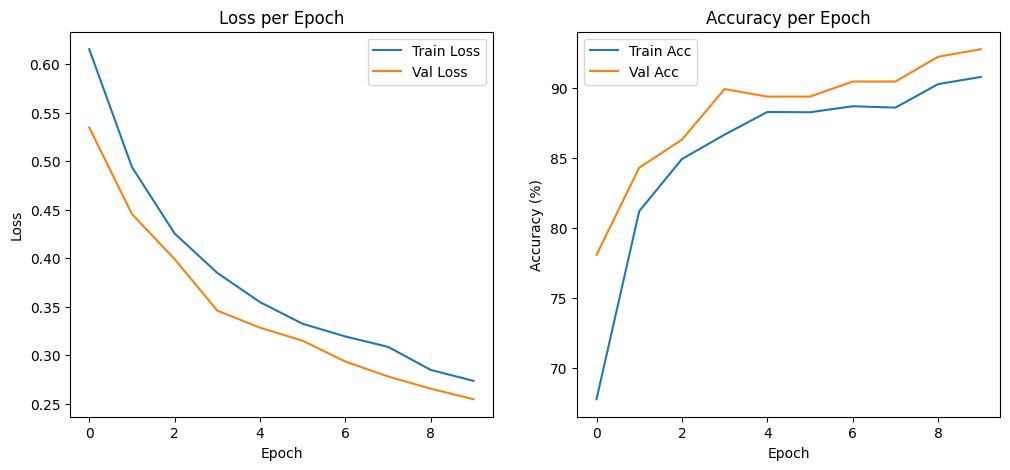

##### Trainig & validation results using our photos + kids photos + the dataset : epoch = 15 , batch size = 64 , lr = 1e-4 

###### Epoch [1/15] Train Loss: 0.5366, Train Acc: 78.94% | Val Loss: 0.4895, Val Acc: 81.99%

###### Epoch [2/15] Train Loss: 0.4516, Train Acc: 83.81% | Val Loss: 0.4152, Val Acc: 85.92%

###### Epoch [3/15] Train Loss: 0.3999, Train Acc: 86.52% | Val Loss: 0.3774, Val Acc: 87.78%

###### Epoch [4/15] Train Loss: 0.3730, Train Acc: 86.80% | Val Loss: 0.3512, Val Acc: 87.63%

###### Epoch [5/15] Train Loss: 0.3470, Train Acc: 87.40% | Val Loss: 0.3110, Val Acc: 90.78%

###### Epoch [6/15] Train Loss: 0.3274, Train Acc: 88.68% | Val Loss: 0.3123, Val Acc: 89.14%

###### Epoch [7/15] Train Loss: 0.3123, Train Acc: 88.81% | Val Loss: 0.2913, Val Acc: 90.49%

###### Epoch [8/15] Train Loss: 0.3020, Train Acc: 89.49% | Val Loss: 0.2954, Val Acc: 88.85%

###### Epoch [9/15] Train Loss: 0.2916, Train Acc: 89.80% | Val Loss: 0.2846, Val Acc: 89.21%

###### Epoch [10/15] Train Loss: 0.2838, Train Acc: 89.56% | Val Loss: 0.2678, Val Acc: 90.35%

###### Epoch [11/15] Train Loss: 0.2828, Train Acc: 89.57% | Val Loss: 0.2686, Val Acc: 89.64%

###### Epoch [12/15] Train Loss: 0.2783, Train Acc: 89.97% | Val Loss: 0.2546, Val Acc: 90.56%

###### Epoch [13/15] Train Loss: 0.2700, Train Acc: 89.86% | Val Loss: 0.2593, Val Acc: 91.21%

###### Epoch [14/15] Train Loss: 0.2581, Train Acc: 90.57% | Val Loss: 0.2523, Val Acc: 90.35%

###### Epoch [15/15] Train Loss: 0.2612, Train Acc: 90.26% | Val Loss: 0.2454, Val Acc: 90.99%

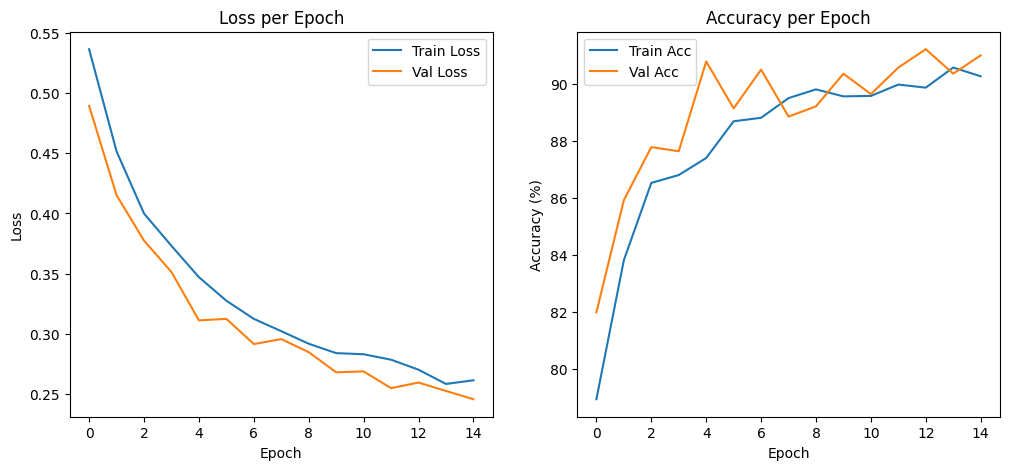

Epoch [1/10] Train Loss: 0.6903, Train Acc: 57.83% | Val Loss: 0.6359, Val Acc: 66.33%
Epoch [2/10] Train Loss: 0.6050, Train Acc: 69.85% | Val Loss: 0.5691, Val Acc: 72.41%
Epoch [3/10] Train Loss: 0.5370, Train Acc: 77.26% | Val Loss: 0.5166, Val Acc: 77.63%
Epoch [4/10] Train Loss: 0.4932, Train Acc: 79.48% | Val Loss: 0.4627, Val Acc: 83.70%
Epoch [5/10] Train Loss: 0.4554, Train Acc: 82.51% | Val Loss: 0.4446, Val Acc: 83.77%
Epoch [6/10] Train Loss: 0.4332, Train Acc: 84.07% | Val Loss: 0.4126, Val Acc: 85.28%
Epoch [7/10] Train Loss: 0.4178, Train Acc: 84.26% | Val Loss: 0.3963, Val Acc: 86.28%
Epoch [8/10] Train Loss: 0.3941, Train Acc: 85.30% | Val Loss: 0.3689, Val Acc: 87.35%
Epoch [9/10] Train Loss: 0.3775, Train Acc: 86.51% | Val Loss: 0.3769, Val Acc: 86.99%
Epoch [10/10] Train Loss: 0.3695, Train Acc: 86.40% | Val Loss: 0.3430, Val Acc: 88.92%

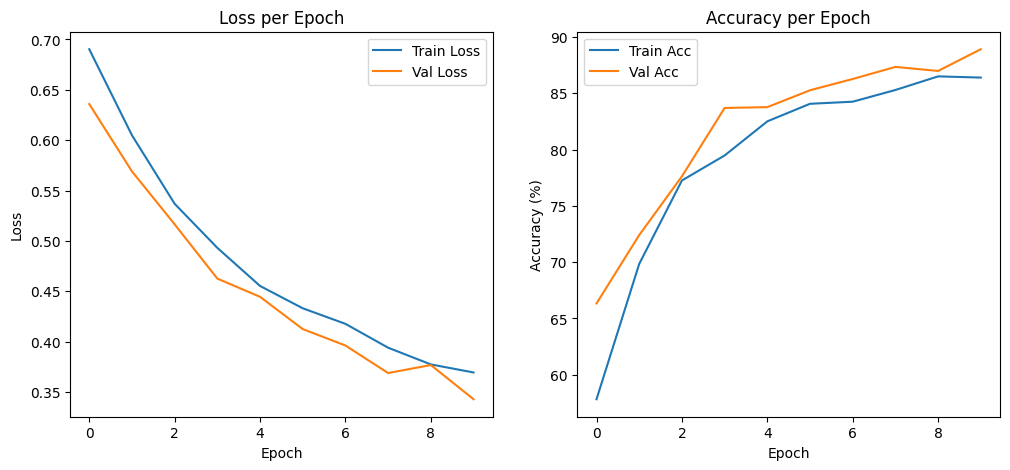